# Particle Scanning & 3D Scoring Pipeline
This notebook runs slice-wise detection on tomograms, post-processes detections into object candidates, evaluates against available centers, and re-scores candidates using a lightweight 3D CNN. It concludes with optional training of a new 3D CNN scorer.

In [2]:
import sys 
sys.path.append("../src")
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import utils
import data
import torch
import postprocess 
import modules
from tqdm import tqdm
from torch.utils.data import DataLoader, random_split 
import pickle
import pytorch_lightning as pl

/data/biosoftware/miniconda3/miniconda3/envs/tomognn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Trained Detector
Load the stage-2 detector (DETR-based) from a checkpoint. Set to `eval()` for inference-only usage.

In [12]:
# load model
# ribosome
model = utils.loadModel("<pathto>/release_model/ribosome", "last.ckpt")
model = model.eval()

# hsp60
# model = utils.loadModel("<pathto>/release_model/hsp60", "last.ckpt")
# model = model.eval()


model at stage  stage 1
model with output classes 2
model receiving class weights tensor([1.0000, 0.6000])
using consistency regularization coef 0.5


/data/biosoftware/miniconda3/miniconda3/envs/tomognn/lib/python3.11/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/home/feity/cryoem/notebooks/../src/utils.py:1397: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will

incompatible parameters []
finish loading parameters


## Build Dataset & Run Inference
Create an `MrcDataset` from the annotations to produce per-slice inputs. Run the detector to generate a candidates DataFrame (`df`) and optional `graphs` for spatial postprocessing.

In [13]:
# dataset from plain mrc
model = model.cuda(0)
# model = model.cpu()

# ribosome
dataset = data.TestDatasetMrc(
    "<pathto>/release_model/data_example/ribosome.mrc",
    norm="hist",
    reshape=800,
    length_for_average=3,
    gap = 1
)
df = postprocess.generatedfBySlice(model, dataset, gap = 1, columns=["ribosome", "None"]) 

# hsp60
# dataset = data.TestDatasetMrc(
#     "<pathto>/release_model/data_example/hsp60.mrc",
#     norm="hist",
#     reshape=800,
#     length_for_average=3,
#     gap = 1
# )
# df = postprocess.generatedfBySlice(model, dataset, gap = 1, columns=["hsp60", "None"]) 



loading test dataset


100%|██████████| 500/500 [01:23<00:00,  5.97it/s]


finish stage1


Stage 2 slices: 100%|██████████| 500/500 [00:23<00:00, 21.12it/s]


## Post-processing Parameters
This step is not used if a 3DCNN refinement network is used. 
Configure thresholds for class-specific filtering and clustering. Steps include:
- Score thresholding per class (`min_prob`) and NMS (`nms`).
- Spatial clustering via DBSCAN with distance penalties to merge proximate detections.
- Marking and filtering rules to cap counts, enforce minimum samples/length, and remove overlaps.

In [14]:
# carried out to find instances from the model output. 
# The step is not necessary if a 3DCNN refinement model is used 
# But it is always recommended to check the training status of the model

df["unlabeled"] = True 
df["label"] = "" 
df["label_id"] = -1

params= {
    "ribosome":{"min_prob":0.4, "nms":0.2, "cluster_params":{"min_samples": 6, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 5}}, 
    "hsp60":{"min_prob":0.4, "nms":0.2, "cluster_params":{"min_samples": 4, "eps": 0.5, "dis_penalty_coef": 2.0*(1/500), "dis_penalty_cutoff": 3, "enlarge": 0.03}}, 
}

mark_and_filter = {
    "ribosome":{"max_cnt":5000, "remove_iou": 0.5, "min_samples":12, "min_length":16, "max_samples":30}, 
    "hsp60":{"max_cnt":5000, "remove_iou": 0.5, "min_samples":5, "min_length":10, "max_samples":30},
}

# ribosome
subdf = postprocess.processClass(df, "ribosome", **params["ribosome"])
postprocess.markFilter(df, "ribosome", subdf, **mark_and_filter["ribosome"]) 

# hsp60
# subdf = postprocess.processClass(df, "hsp60", **params["hsp60"])
# postprocess.markFilter(df, "hsp60", subdf, **mark_and_filter["hsp60"])

6 0.5 0.004 5
number of instances in class  1099


## Visualize Detections on a Slice
Select a slice `z` and overlay filtered detections as bounding boxes to sanity-check spatial coverage and class assignments.

/tmp/ipykernel_20830/1095585570.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/notebooks/../src/utils.py:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


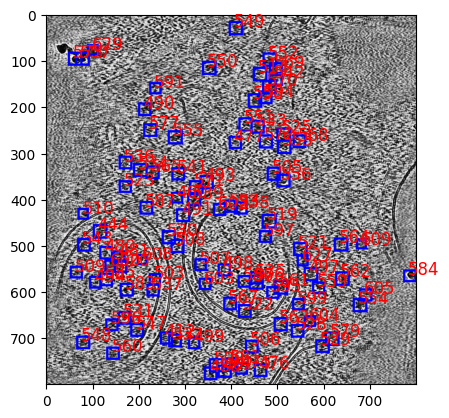

In [15]:
take = 250

# img = retdict["images"][take]
img = dataset.__getitem__(pos=take)["pixel_values"]

subdf = df[df["z"] == take] 
subdf = subdf[subdf["label_id"] != -1]

bboxes = subdf[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])

img[0] = img[1]
img[2] = img[1]
labels = {"bboxes": bboxes, "labels": list(subdf['label_id'].astype(str))} 
utils.drawannotation(img, labels, font_size=12)
plt.show()
plt.close()


## Load Ground-Truth Centers
Load reference particle centers for the target tomogram; used to compute matching-based metrics against predictions.

In [16]:
# ribosome
labels = np.loadtxt("<pathto>/release_model/data_example/ribosome_label.txt") 

# hsp60
# labels = np.loadtxt("<pathto>/release_model/data_example/hsp60_label.txt")

## Compute Prediction Centers & Metrics
Aggregate per-slice detections into candidate centers, match to ground-truth, and compute metrics such as AUPR-like scores, recall at distance thresholds, and overall counts.

In [17]:
# ribosome
score, predict_center, ids = postprocess.getPredictionCenters(df, "ribosome", image_size=1024, top_n=20)
# hsp60
# score, predict_center, ids = postprocess.getPredictionCenters(df, "hsp60", image_size=1024, top_n=20)

idx = np.argsort(-score)
score = score[idx]
predict_center = predict_center[idx]
matches, match_dists, closest = postprocess.match_and_find_closest(predict_center, labels)
t, cnt = postprocess.calculate_metrics(matches, match_dists, score, threshold=20), len(idx)
print(t)
print("final score:", t["aupr2"]*t["cnts"]/len(labels))

{'auroc': 0.6910545551791762, 'aupr': 0.8071909363379195, 'aupr2': 0.8078685576158569, 'cnts': 632}
final score: 0.6726916052875119
